In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# csvs = glob.glob("output/*.csv")
# df = pd.concat([pd.read_csv(cvs) for cvs in csvs])
# df.drop_duplicates(subset=["processo_id"], inplace=True)

In [110]:
# df = pd.read_feather("output/adi.feather")
df = pd.read_csv("output/judex-mini_ADI_4000-4100.csv")

In [111]:
df.drop(columns=["html"], inplace=True)

In [112]:
df.drop_duplicates(subset=["incidente"], inplace=True)

In [113]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 127
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   incidente       89 non-null     int64  
 1   classe          89 non-null     object 
 2   processo_id     89 non-null     int64  
 3   numero_unico    89 non-null     object 
 4   meio            89 non-null     object 
 5   publicidade     89 non-null     object 
 6   badges          89 non-null     object 
 7   assuntos        89 non-null     object 
 8   data_protocolo  89 non-null     object 
 9   orgao_origem    89 non-null     object 
 10  origem          89 non-null     object 
 11  numero_origem   88 non-null     object 
 12  volumes         89 non-null     int64  
 13  folhas          89 non-null     int64  
 14  apensos         54 non-null     float64
 15  relator         89 non-null     object 
 16  primeiro_autor  87 non-null     object 
 17  partes          89 non-null     object 
 

In [ ]:
andamentos = df[["andamentos", "incidente"]].set_index("incidente")

andamentos["andamentos"] = andamentos["andamentos"].apply(json.loads)

andamentos_exploded = andamentos.explode("andamentos")
andamentos_exploded.reset_index(inplace=True)

normalized = pd.json_normalize(andamentos_exploded["andamentos"])

andamentos = pd.concat([andamentos_exploded[["incidente"]], normalized], axis=1)
andamentos.head()

,incidente,index_num,data,nome,complemento,julgador,link_descricao,link
0,2584941,67.0,20/06/2017,BAIXA AO ARQUIVO DO STF,None,None,None,None
1,2584941,66.0,20/06/2017,DECISÃO DE JULGAMENTO (LEI 9.868/99) PUBLICADA...,em 16/6/2017,None,None,None
2,2584941,65.0,13/06/2017,TRANSITADO(A) EM JULGADO,em 10/6/2017,None,CERTIDÃO DE TRÂNSITO EM JULGADO,https://portal.stf.jus.br/processos/downloadPe...
3,2584941,64.0,02/06/2017,"PUBLICADO ACÓRDÃO, DJE",DATA DE PUBLICAÇÃO DJE 02/06/2017 - ATA Nº 81/...,None,INTEIRO TEOR DO ACÓRDÃO,https://portal.stf.jus.br/processos/downloadPe...
4,2584941,63.0,26/05/2017,DECISÃO DE JULGAMENTO (LEI 9.868/99) PUBLICADA...,None,None,None,None
...,...,...,...,...,...,...,...,...
4847,2624551,5.0,17/06/2008,DESPACHO,"Em 12/6/2008: ""[...] Devido à relevância da ma...",None,None,None
4848,2624551,4.0,12/06/2008,CONCLUSOS AO(À) RELATOR(A),None,None,None,None
4849,2624551,3.0,12/06/2008,DISTRIBUÍDO,MIN. RICARDO LEWANDOWSKI,None,None,None
4850,2624551,2.0,12/06/2008,AUTUADO,None,None,None,None


In [118]:
andamentos.to_feather("output/andamentos.feather")

In [119]:
print("Percentage of NaN values in each column:")
print(f"{andamentos.isna().mean() * 100}")

Percentage of NaN values in each column:
incidente          0.000000
index_num          0.061830
data               0.061830
nome               0.061830
complemento       19.703215
julgador          96.022259
link_descricao    89.839242
link              89.839242
dtype: float64


In [120]:
andamentos['julgador'].value_counts()

julgador
TRIBUNAL PLENO                     47
TRIBUNAL PLENO - SESSÃO VIRTUAL    46
MIN. ROSA WEBER                    15
MIN. DIAS TOFFOLI                  10
MIN. EROS GRAU                      8
MIN. GILMAR MENDES                  8
MIN. RICARDO LEWANDOWSKI            7
MIN. LUIZ FUX                       7
MIN. AYRES BRITTO                   6
MIN. MENEZES DIREITO                6
MIN. CELSO DE MELLO                 6
MIN. LUÍS ROBERTO BARROSO           5
MIN. ALEXANDRE DE MORAES            4
MIN. FLÁVIO DINO                    3
MIN. CÁRMEN LÚCIA                   2
MIN. TEORI ZAVASCKI                 2
MIN. MARCO AURÉLIO                  2
MIN. EDSON FACHIN                   2
MIN. JOAQUIM BARBOSA                2
MIN. ELLEN GRACIE                   2
PRESIDÊNCIA                         1
MIN. CEZAR PELUSO                   1
MIN. NUNES MARQUES                  1
Name: count, dtype: int64

In [121]:
andamentos['link_descricao'].value_counts()

link_descricao
DESPACHO                           220
DECISÃO DE JULGAMENTO              103
INTEIRO TEOR DO ACÓRDÃO             54
DECISÃO MONOCRÁTICA                 40
CERTIDÃO DE TRÂNSITO EM JULGADO     38
CERTIDÃO                            23
COMUNICAÇÃO ASSINADA                 6
MANIFESTAÇÃO DA PGR                  4
VISTA À PGR                          2
VISTA AO AGU                         2
CERTIDÃO DE JULGAMENTO               1
Name: count, dtype: int64

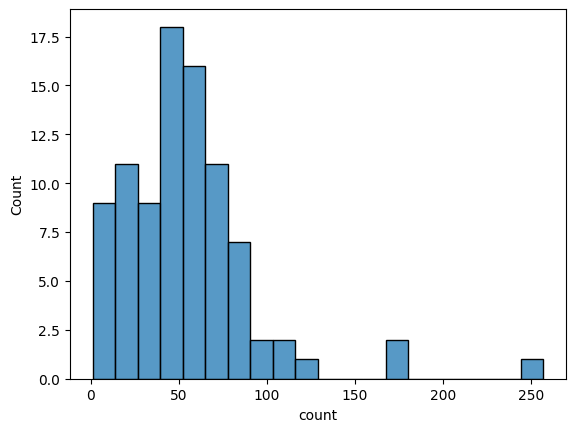

In [134]:
# mean incidentes per processo
sns.histplot(andamentos['incidente'].value_counts(), bins=20);

In [143]:
andamentos['incidente'].value_counts().describe().round(2)

count     89.00
mean      54.52
std       38.74
min        1.00
25%       32.00
50%       51.00
75%       68.00
max      257.00
Name: count, dtype: float64

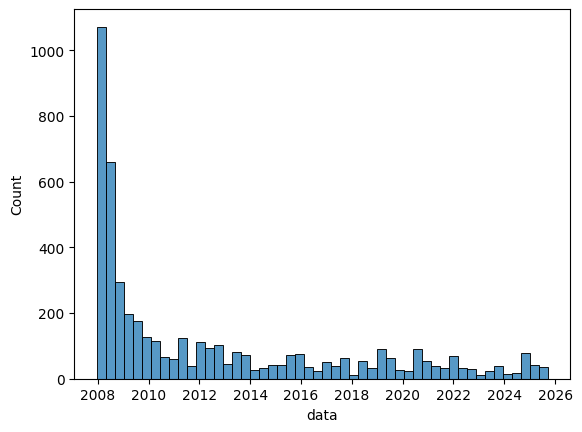

In [ ]:
# datas
andamentos['data'] = pd.to_datetime(andamentos['data'])
sns.histplot(andamentos['data'], bins=50);

In [ ]:
# embeddings clustering

In [ ]:
# classificacao